# 254. Does seed extension keep notebook 244's cases?

Notebook 244 found 87 cases where kmerseek places a short human Swiss-Prot feature (under
60 aa) on a target protein at 50-90% identity. On the same cases every comparison tool calls
a region covering most of the protein. Those searches ran on the midi-plus run (1-2 Sept 2026) with
`docker.io/olgabot/kmerseek:2026-08-24-reduced-alphabets`, which matches exact k-mers only
and does not extend them.

Notebook 252 searched with ungapped extension (kmerseek PRs #88 and #89). Each exact match
is grown one residue at a time on both sides. Growth stops when the score falls a set amount
below its best. There, 674 of kmerseek's 1,214 correct calls covered the whole target protein, which
is what notebook 244 says the other tools do. This notebook asks whether extension does the
same to the 87 cases.

**Decision rule, written before any search was run.**

- If the extended call keeps IoU within 0.05 of the exact call on at least 70 of the 87
  cases, and still beats the best comparison tool's IoU on at least as many cases as exact
  does, extension is safe as the paper's default for placement.
- Otherwise the paper uses exact seeds for placing features, and describes extension only as
  the setting for reaching lower identity (notebook 232, notebook 252).

"The exact call" in the rule is the new build searched without extension (condition b
below), so that extension is the only difference between the two sides. The old build's
value (condition a) is shown beside it. If the rule gives a different answer with a in
place of b, the last cell says so.

**What this test can and cannot say.** The 87 cases were chosen on the exact-seed results,
so exact seeds win them by construction. This test asks only whether extension keeps them.
It is not an unbiased estimate of how well either setting places features.

**Conditions**, all with each case's own kmerseek setting from notebook 244 (alphabet, k,
low-complexity mask on):

| | build | seeds | where the number comes from |
|---|---|---|---|
| a | midi-plus image `2026-08-24-reduced-alphabets` | exact | `kmerseek_iou` in `tables/244_hero_candidates.csv`; no new search |
| b | notebook 252's image, `docker.io/olgabot/kmerseek@sha256:f08eeda6...` (kmerseek 90c581a) | exact | new search, no extension options |
| c | the same image | extended | new search with `--extend-mismatch-penalty` and `--extend-xdrop`, against an index built with the same two options and `--ka-reference-shuffles`, as notebook 252's `main.nf` builds it |

b against a separates the change of build from extension. c against b answers the question.

**Definitions.**

- *IoU*: the overlap between a call and the Swiss-Prot feature, divided by their union.
- *Call*: a kmerseek region on the human protein, labelled with a feature type. The region
  takes the type when it covers at least half of a feature of that type on the target
  protein (the pipeline's transfer rule).
- *Lands*: at least 80% of the call is inside the human feature and the call covers at
  least 30% of it (notebook 244).
- *Spans the whole target*: the call's interval on the target protein runs from its first
  residue to its last. This is notebook 252's "one possible position" count.
- *Karlin-Altschul fit*: the index estimates, from 200 of its own sequences searched
  against itself and the same sequences shuffled, how often a score this high arises by
  chance. With a fit, a region gets `region_ka_evalue`; without one it is still extended,
  and `region_ka_evalue` is empty.

**Where each number comes from.**

| quantity | function |
|---|---|
| the searches | `scripts/run_254_extension_searches.py`: whole target proteome (the significance filter depends on how many proteins are searched), the midi-plus search options (`--threshold 0 --min-shared-kmers 2 --max-query-pvalue 0.05 --min-region-score 1.3`) for b and c alike, human queries restricted to the 42 proteins of the 87 cases |
| extension settings | `tables/254_extension_arms.tsv`: penalty and give-up margin (`--extend-xdrop`) from `nextflow-runs/deep-twilight-controls/assets/arms.tsv`; for the three settings not in that table, the alphabet's own values (they are the same at every k there) and the number of reference shuffles measured with `scripts/measure_ka_fit_recovery.py` on notebook 252's database |
| calls, inside, cover, IoU | `scripts/score_254_extension.py`, which calls `reduce_one` from `scripts/reduce_swissprot_instance_landing.py` unchanged: `load_regions` with its Bonferroni p < 0.05 filter, ranking by `region_enrichment`, and the transfer rule |
| comparison-tool IoU | `tables/244_hero_candidates.csv`, the best IoU of Foldseek, ProstT5, Reseek, phmmer, MMseqs2 and MMseqs2 iterative on the same feature |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display

sys.path.insert(0, str(Path.cwd()))
import hero_example_utils as he
import hero_extension_utils as hx
import mhc_region_utils as mu

plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight", "font.size": 9.5})
pl.Config.set_tbl_rows(100)
pl.Config.set_tbl_cols(30)
pl.Config.set_tbl_width_chars(250)
pl.Config.set_fmt_str_lengths(40)

FIG = Path("../figures")
TAB = Path("../tables")

cases = hx.load_cases()
print(f"cases admitted under all criteria: {cases.height}")
print(f"human query proteins: {cases['query'].n_unique()}")
print(cases.group_by("alphabet", "ksize").len().sort("len", descending=True))

cases admitted under all criteria: 87
human query proteins: 42
shape: (5, 3)
┌──────────────────────────┬───────┬─────┐
│ alphabet                 ┆ ksize ┆ len │
│ ---                      ┆ ---   ┆ --- │
│ str                      ┆ i64   ┆ u32 │
╞══════════════════════════╪═══════╪═════╡
│ sdm12                    ┆ 6     ┆ 31  │
│ hp_thomas_dill_no_c2     ┆ 19    ┆ 21  │
│ mmseqs12                 ┆ 7     ┆ 16  │
│ hp_kyte_doolittle2       ┆ 19    ┆ 15  │
│ hp_lehninger_c_nonpolar2 ┆ 18    ┆ 4   │
└──────────────────────────┴───────┴─────┘


## 1. Settings and index fits

One row per kmerseek setting the 87 cases use. `penalty` is the score lost per mismatched
position during extension; `xdrop` is how far the score may fall below its best before
extension stops. Then, per target proteome, whether the extended index got a
Karlin-Altschul fit.

In [2]:
arms = pl.read_csv(hx.ARMS_TSV, separator="\t")
print(arms.drop("source"))
print()
fits = hx.index_fits()
print(
    f"extended indexes: {fits.height}; with a Karlin-Altschul fit: {fits['has_ka_fit'].sum()}"
)
print(fits.sort("alphabet", "species"))

shape: (5, 5)
┌──────────────────────────┬───────┬─────────┬───────┬───────────────────────┐
│ alphabet                 ┆ ksize ┆ penalty ┆ xdrop ┆ ka_reference_shuffles │
│ ---                      ┆ ---   ┆ ---     ┆ ---   ┆ ---                   │
│ str                      ┆ i64   ┆ f64     ┆ f64   ┆ i64                   │
╞══════════════════════════╪═══════╪═════════╪═══════╪═══════════════════════╡
│ hp_kyte_doolittle2       ┆ 19    ┆ 1.57    ┆ 6.28  ┆ 1                     │
│ hp_lehninger_c_nonpolar2 ┆ 18    ┆ 1.52    ┆ 6.08  ┆ 1                     │
│ hp_thomas_dill_no_c2     ┆ 19    ┆ 1.62    ┆ 6.47  ┆ 1                     │
│ mmseqs12                 ┆ 7     ┆ 0.22    ┆ 0.89  ┆ 1                     │
│ sdm12                    ┆ 6     ┆ 0.24    ┆ 0.94  ┆ 1                     │
└──────────────────────────┴───────┴─────────┴───────┴───────────────────────┘

extended indexes: 24; with a Karlin-Altschul fit: 24
shape: (24, 6)
┌─────────────┬──────────────────────────┬──────

## 2. Does the new build reproduce the old exact result? (b against a)

The rule set before the run: if b does not reproduce `kmerseek_iou` within 0.05 on at least
80 of 87 cases, the notebook stops here. A change of build would have to be explained
before extension can be judged.

b is scored on notebook 244's own definition: the best landed call over every target
protein.

In [3]:
scored = hx.load_scored()
d = cases.join(scored, on=hx.KEY, how="left", validate="1:1")
assert d.height == hx.N_CASES

d = d.with_columns(
    old_exact_iou=pl.col("kmerseek_iou"),
    new_exact_land_iou=pl.col("exact_all_targets_land_iou").fill_null(0.0),
    new_exact_iou=pl.col("exact_call_iou").fill_null(0.0),
    extended_iou=pl.col("extended_call_iou").fill_null(0.0),
)
d = d.with_columns(
    build_diff=(pl.col("new_exact_land_iou") - pl.col("old_exact_iou")),
)
n_repro = (d["build_diff"].abs() <= hx.KEEP_TOL).sum()
BUILD_OK = n_repro >= hx.BUILD_CHECK_MIN
print(
    f"b reproduces a within {hx.KEEP_TOL}: {n_repro} of {d.height} cases "
    f"(needed: {hx.BUILD_CHECK_MIN}) -> {'go on' if BUILD_OK else 'STOP'}"
)
print(
    f"b has no landed call on the feature: {d['exact_all_targets_land_iou'].null_count()} cases"
)
moved = d.filter(pl.col("build_diff").abs() > hx.KEEP_TOL)
print(f"cases where b moved by more than {hx.KEEP_TOL}: {moved.height}")
print(
    moved.select(
        "gene",
        "swissprot_description",
        "species",
        "kmerseek_chosen_arm",
        pl.col("old_exact_iou").round(3),
        pl.col("exact_all_targets_land_iou").round(3),
        "exact_all_targets_land_target",
        "target",
    )
)

b reproduces a within 0.05: 80 of 87 cases (needed: 80) -> go on
b has no landed call on the feature: 4 cases
cases where b moved by more than 0.05: 7
shape: (7, 8)
┌─────────┬───────────────────────┬─────────────┬──────────────────────────────────────────┬───────────────┬────────────────────────────┬───────────────────────────────┬────────┐
│ gene    ┆ swissprot_description ┆ species     ┆ kmerseek_chosen_arm                      ┆ old_exact_iou ┆ exact_all_targets_land_iou ┆ exact_all_targets_land_target ┆ target │
│ ---     ┆ ---                   ┆ ---         ┆ ---                                      ┆ ---           ┆ ---                        ┆ ---                           ┆ ---    │
│ str     ┆ str                   ┆ str         ┆ str                                      ┆ f64           ┆ f64                        ┆ str                           ┆ str    │
╞═════════╪═══════════════════════╪═════════════╪══════════════════════════════════════════╪═══════════════╪═══════════

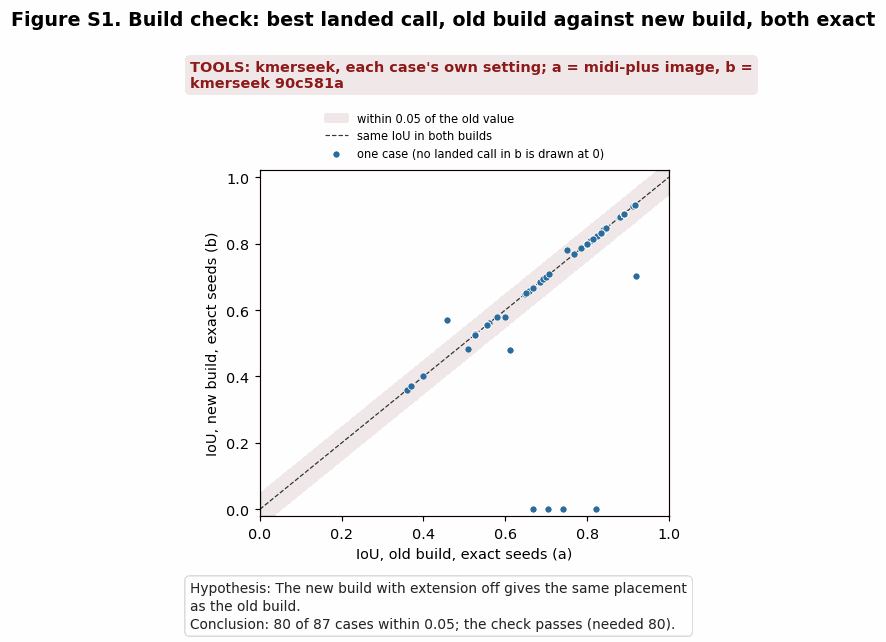

In [4]:
fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.fill_between(
    [0, 1],
    [-hx.KEEP_TOL, 1 - hx.KEEP_TOL],
    [hx.KEEP_TOL, 1 + hx.KEEP_TOL],
    color="#E6E6E6",
    zorder=0,
    label=f"within {hx.KEEP_TOL} of the old value",
)
ax.plot(
    [0, 1],
    [0, 1],
    color="#333333",
    lw=0.8,
    ls="--",
    zorder=1,
    label="same IoU in both builds",
)
ax.scatter(
    d["old_exact_iou"],
    d["new_exact_land_iou"],
    s=22,
    color=hx.CALL_STYLE["exact"]["facecolor"],
    edgecolor="white",
    lw=0.5,
    zorder=3,
    label="one case (no landed call in b is drawn at 0)",
)
ax.set_xlim(0, 1)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("IoU, old build, exact seeds (a)")
ax.set_ylabel("IoU, new build, exact seeds (b)")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), fontsize=7.5, frameon=False)
mu.finish_figure(
    fig,
    FIG / "254_build_check.png",
    tools=f"kmerseek, each case's own setting; a = midi-plus image, b = kmerseek 90c581a",
    hypothesis="The new build with extension off gives the same placement as the old build.",
    conclusion=f"{n_repro} of {d.height} cases within {hx.KEEP_TOL}; "
    f"{'the check passes' if BUILD_OK else 'the check fails'} (needed {hx.BUILD_CHECK_MIN}).",
    title="Figure S1. Build check: best landed call, old build against new build, both exact",
)

**Why 7 cases moved.** In COL9A1 "Collagen-like 6" in zebrafish, b's best landed call is on
another zebrafish protein. On the case's own target the call and its IoU are unchanged.
In PAK1IP1 "WD 5" in chicken, b makes no call on the feature. In the other five, b's exact
call starts where a's did but runs further, so less than 80% of it is inside the feature and
it no longer lands. The cell below checks one of these, MYB "H-T-H motif" in arabidopsis. It
reruns the old image on that one query (`scripts/rerun_254_old_build_myb.sh`) and prints
both builds' regions on the case's target.

In [5]:
old = pl.read_csv(hx.RUN_DIR / "oldcheck" / "old_on.csv").filter(
    pl.col("target_name").str.contains("|Q6R032|", literal=True)
    & pl.col("region_start").is_between(100, 130)
)
new = (
    pl.scan_parquet(
        hx.RUN_DIR
        / "exact"
        / "human_vs_arabidopsis.hp_kyte_doolittle2.k19.lctrue.regions.parquet"
    )
    .filter(
        pl.col("query_name").str.contains("|P10242|", literal=True)
        & pl.col("target_name").str.contains("|Q6R032|", literal=True)
        & pl.col("region_start").is_between(100, 130)
    )
    .collect()
)
cols = [
    "region_start",
    "region_end",
    "target_start",
    "target_end",
    "region_n_shared_kmers",
]
print(
    "MYB (P10242) H-T-H motif 115-138 against arabidopsis Q6R032, hp_kyte_doolittle2 k19, exact seeds"
)
print("old build, rerun on this query:")
print(old.select(cols).sort("region_start", "target_start"))
print("new build:")
print(new.select(cols).sort("region_start", "target_start"))
r = new.filter(pl.col("region_start") == 113).row(0, named=True)
print(
    f"new region {r['region_start']}-{r['region_end']}: {r['region_end'] - r['region_start']} residues, "
    f"{r['region_n_shared_kmers']} shared k-mers = length - k + 1, so every k-mer along it is shared"
)

MYB (P10242) H-T-H motif 115-138 against arabidopsis Q6R032, hp_kyte_doolittle2 k19, exact seeds
old build, rerun on this query:
shape: (9, 5)
┌──────────────┬────────────┬──────────────┬────────────┬───────────────────────┐
│ region_start ┆ region_end ┆ target_start ┆ target_end ┆ region_n_shared_kmers │
│ ---          ┆ ---        ┆ ---          ┆ ---        ┆ ---                   │
│ i64          ┆ i64        ┆ i64          ┆ i64        ┆ i64                   │
╞══════════════╪════════════╪══════════════╪════════════╪═══════════════════════╡
│ 113          ┆ 138        ┆ 148          ┆ 173        ┆ 7                     │
│ 119          ┆ 138        ┆ 341          ┆ 360        ┆ 1                     │
│ 120          ┆ 139        ┆ 155          ┆ 174        ┆ 1                     │
│ 120          ┆ 139        ┆ 342          ┆ 361        ┆ 1                     │
│ 121          ┆ 140        ┆ 156          ┆ 175        ┆ 1                     │
│ 121          ┆ 140        ┆ 343    

The old build reports 113-138 with 7 shared k-mers. The rest of the same diagonal (target =
query + 35) comes out as separate pieces: 120-139, 121-140, 122-141 and 123-145. The pieces
start at the k-mers that also match a second place on the target (341-363). The new build
reports the unbroken run, 113-145, as one call with all 14 k-mers. The change is in how exact runs are put together, not in
extension. The check passes, so the comparison goes on, but the margin is zero: 80 of 87.

## 3. Exact against extended, per case

One row per case. IoU columns: `old exact` is a, `new exact` is b, `extended` is c. For b
and c the call is the best call of the case's feature type on the case's own target
protein, landed or not. The comparison tools' IoU is taken the same way. An empty call reads as
IoU 0. `call aa`, `inside` and the two E-values are for the extended call. `identity %` is
the identity of notebook 244's exact region. `whole target` is true when the extended call
covers the target protein from end to end.

In [6]:
d = d.with_columns(
    ext_minus_exact=pl.col("extended_iou") - pl.col("new_exact_iou"),
    ext_minus_old=pl.col("extended_iou") - pl.col("old_exact_iou"),
    ext_spans=pl.col("extended_spans_whole_target").fill_null(False),
    ext_has_call=pl.col("extended_call_iou").is_not_null(),
)
table = d.select(
    "gene",
    pl.col("swissprot_description").alias("feature"),
    "species",
    pl.col("feature_length_aa").alias("feature aa"),
    pl.col("identity_pct_region").alias("identity %"),
    pl.col("old_exact_iou").round(3).alias("old exact"),
    pl.col("new_exact_iou").round(3).alias("new exact"),
    pl.col("extended_iou").round(3).alias("extended"),
    pl.col("extended_call_length_aa").alias("call aa"),
    pl.col("extended_call_inside").round(3).alias("inside"),
    pl.col("ext_spans").alias("whole target"),
    pl.col("extended_region_evalue").alias("region_evalue"),
    pl.col("extended_region_ka_evalue").alias("region_ka_evalue"),
    pl.col("best_tool_iou").round(3).alias("best tool"),
    "best_tool",
    pl.col("kmerseek_chosen_arm")
    .str.replace("kmerseek.", "", literal=True)
    .alias("setting"),
    "query",
    "target",
).sort("extended")
table.write_csv(TAB / "254_extension_per_case.csv")
print(table)

shape: (87, 18)
┌─────────┬────────────────────┬─────────────┬────────────┬────────────┬───────────┬───────────┬──────────┬─────────┬────────┬──────────────┬───────────────┬──────────────────┬───────────┬───────────────────┬───────────────────┬────────┬────────────┐
│ gene    ┆ feature            ┆ species     ┆ feature aa ┆ identity % ┆ old exact ┆ new exact ┆ extended ┆ call aa ┆ inside ┆ whole target ┆ region_evalue ┆ region_ka_evalue ┆ best tool ┆ best_tool         ┆ setting           ┆ query  ┆ target     │
│ ---     ┆ ---                ┆ ---         ┆ ---        ┆ ---        ┆ ---       ┆ ---       ┆ ---      ┆ ---     ┆ ---    ┆ ---          ┆ ---           ┆ ---              ┆ ---       ┆ ---               ┆ ---               ┆ ---    ┆ ---        │
│ str     ┆ str                ┆ str         ┆ i64        ┆ f64        ┆ f64       ┆ f64       ┆ f64      ┆ i64     ┆ f64    ┆ bool         ┆ f64           ┆ f64              ┆ f64       ┆ str               ┆ str               ┆ st

## 4. Figure 1: exact IoU against extended IoU

One dot per case. A dot on the dashed line kept its IoU; below the line, extension lowered
it. The grey band is the rule's tolerance of 0.05.

cases within 0.05: 11 of 87
extension lowers IoU by more than 0.05: 66
extension raises IoU by more than 0.05: 10
extended call spans the whole target: 0
no extended call on the target: 27
median IoU: exact 0.800, extended 0.173


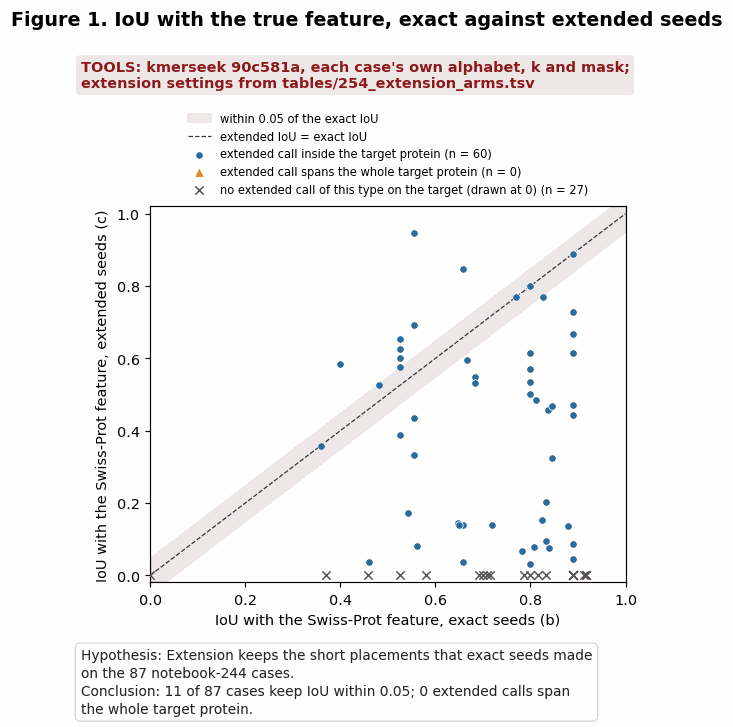

In [7]:
fig, ax = plt.subplots(figsize=(5.2, 5.0))
ax.fill_between(
    [0, 1],
    [-hx.KEEP_TOL, 1 - hx.KEEP_TOL],
    [hx.KEEP_TOL, 1 + hx.KEEP_TOL],
    color="#E6E6E6",
    zorder=0,
    label=f"within {hx.KEEP_TOL} of the exact IoU",
)
ax.plot(
    [0, 1],
    [0, 1],
    color="#333333",
    lw=0.8,
    ls="--",
    zorder=1,
    label="extended IoU = exact IoU",
)
groups = [
    (
        d.filter(pl.col("ext_has_call") & ~pl.col("ext_spans")),
        dict(marker="o", color="#2B6C9E", s=24),
        "extended call inside the target protein",
    ),
    (
        d.filter(pl.col("ext_spans")),
        dict(marker="^", color="#D98C1F", s=40),
        "extended call spans the whole target protein",
    ),
    (
        d.filter(~pl.col("ext_has_call")),
        dict(marker="x", color="#555555", s=30),
        "no extended call of this type on the target (drawn at 0)",
    ),
]
for g, style, label in groups:
    ax.scatter(
        g["new_exact_iou"],
        g["extended_iou"],
        zorder=3,
        lw=1 if style["marker"] == "x" else 0.5,
        edgecolor=None if style["marker"] == "x" else "white",
        label=f"{label} (n = {g.height})",
        **style,
    )
ax.set_xlim(0, 1)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("IoU with the Swiss-Prot feature, exact seeds (b)")
ax.set_ylabel("IoU with the Swiss-Prot feature, extended seeds (c)")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), fontsize=7.5, frameon=False)
n_keep = (d["ext_minus_exact"].abs() <= hx.KEEP_TOL).sum()
print(f"cases within {hx.KEEP_TOL}: {n_keep} of {d.height}")
print(
    f"extension lowers IoU by more than {hx.KEEP_TOL}: {(d['ext_minus_exact'] < -hx.KEEP_TOL).sum()}"
)
print(
    f"extension raises IoU by more than {hx.KEEP_TOL}: {(d['ext_minus_exact'] > hx.KEEP_TOL).sum()}"
)
print(f"extended call spans the whole target: {d['ext_spans'].sum()}")
print(f"no extended call on the target: {(~d['ext_has_call']).sum()}")
print(
    f"median IoU: exact {d['new_exact_iou'].median():.3f}, extended {d['extended_iou'].median():.3f}"
)
mu.finish_figure(
    fig,
    FIG / "254_exact_vs_extended_iou.png",
    tools="kmerseek 90c581a, each case's own alphabet, k and mask; extension settings from tables/254_extension_arms.tsv",
    hypothesis="Extension keeps the short placements that exact seeds made on the 87 notebook-244 cases.",
    conclusion=f"{n_keep} of {d.height} cases keep IoU within {hx.KEEP_TOL}; "
    f"{d['ext_spans'].sum()} extended calls span the whole target protein.",
    title="Figure 1. IoU with the true feature, exact against extended seeds",
)

### Why some cases have no extended call

A case has no extended call when no extended region on its target passes the landing
reduction's filter and carries the feature's label. The cell below lists, for each such
case, the extended region that overlaps the human feature most, before any filter. The
filter is a Poisson test on shared k-mers, Bonferroni-corrected. Extension adds residues
without adding shared k-mers, while the expected count grows with the region's length.

In [8]:
rows = []
for r in d.filter(~pl.col("ext_has_call")).iter_rows(named=True):
    x = hx.extended_regions_over_feature(r)
    top = x.row(0, named=True) if x.height else {}
    rows.append(
        dict(
            gene=r["gene"],
            feature=r["swissprot_description"],
            species=r["species"],
            n_regions_over_feature=x.height,
            any_pass_filter=(
                bool((x["bonferroni_p"] < 0.05).any()) if x.height else None
            ),
            **{
                k: top.get(k)
                for k in (
                    "region_start",
                    "region_end",
                    "region_length",
                    "region_n_shared_kmers",
                    "region_expected_shared_kmers",
                    "bonferroni_p",
                    "region_evalue",
                )
            },
        )
    )
no_call = pl.DataFrame(rows)
print(no_call)
n_filtered = no_call.filter(pl.col("n_regions_over_feature") > 0).height
print(
    f"cases with no extended call: {no_call.height}; with an extended region over the feature that fails "
    f"the Bonferroni filter: {n_filtered}; with no extended region over the feature: {no_call.height - n_filtered}"
)

shape: (27, 12)
┌─────────┬───────────────────────────────────┬─────────────┬────────────────────────┬─────────────────┬──────────────┬────────────┬───────────────┬───────────────────────┬──────────────────────────────┬──────────────┬───────────────┐
│ gene    ┆ feature                           ┆ species     ┆ n_regions_over_feature ┆ any_pass_filter ┆ region_start ┆ region_end ┆ region_length ┆ region_n_shared_kmers ┆ region_expected_shared_kmers ┆ bonferroni_p ┆ region_evalue │
│ ---     ┆ ---                               ┆ ---         ┆ ---                    ┆ ---             ┆ ---          ┆ ---        ┆ ---           ┆ ---                   ┆ ---                          ┆ ---          ┆ ---           │
│ str     ┆ str                               ┆ str         ┆ i64                    ┆ bool            ┆ i64          ┆ i64        ┆ i64           ┆ i64                   ┆ f64                          ┆ f64          ┆ f64           │
╞═════════╪═════════════════════════════════

## 5. Figure 2: COL9A1 "Collagen-like 7" in chicken

Human COL9A1 (P20849) against chicken COL9A1 (P12106). Each protein is a line with its
Swiss-Prot features as boxes; the case's feature has a black outline. Under each protein,
one bar per call: the old build's exact call, the new build's exact call and the extended
call, on that protein's own coordinates.

human feature 655-712 (58 aa)
old exact call: human 669-700, chicken 667-698, IoU 0.561
exact call: human 669-700, chicken 667-698, IoU 0.561, inside 1.000, region_evalue 1488.6935702376752, region_ka_evalue None
extended call: human 226-921, chicken 224-919, IoU 0.082, inside 0.082, region_evalue 38.57830564061762, region_ka_evalue None


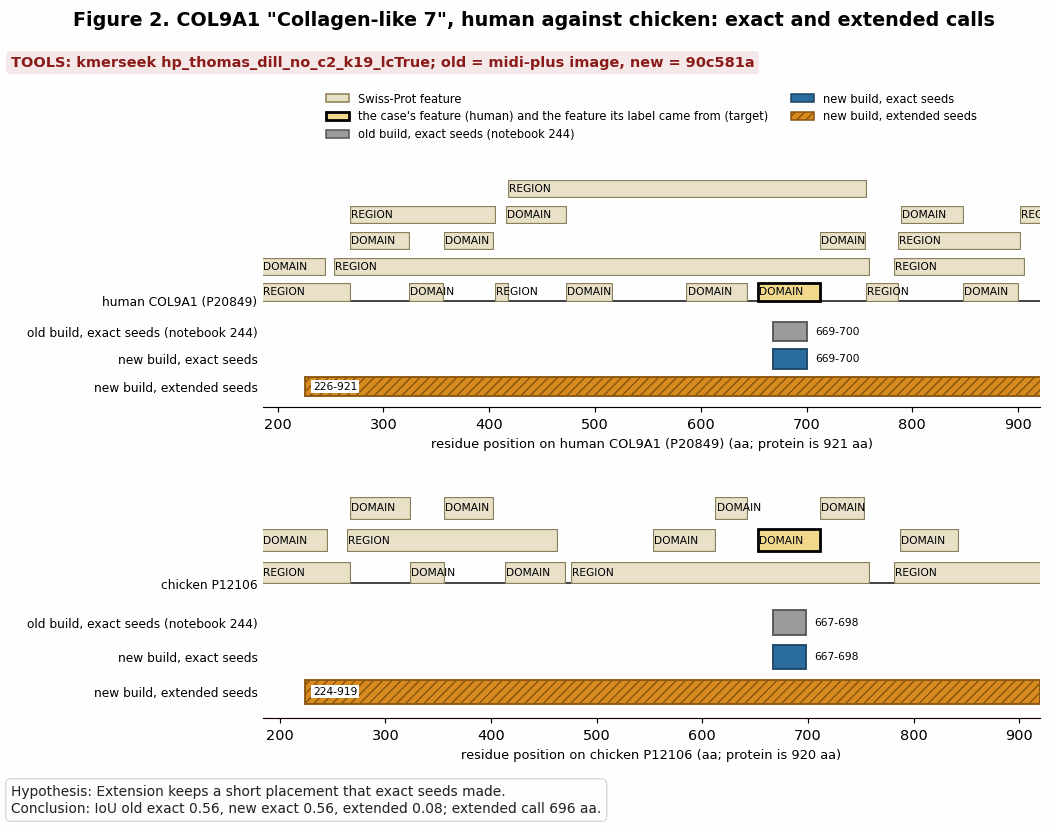

In [9]:
HERO = dict(
    gene="COL9A1",
    species="chicken",
    target="P12106",
    swissprot_description="Collagen-like 7",
)
hero = d.filter(**HERO)
assert hero.height == 1, hero.height
h = hero.row(0, named=True)
land = (
    he.load_landing()
    .filter(
        (pl.col("arm") == h["kmerseek_chosen_arm"])
        & (pl.col("species") == h["species"])
        & (pl.col("accession") == h["query"])
        & (pl.col("pfam_id") == h["feature_type"])
        & (pl.col("domain_start") == h["feature_start"])
        & (pl.col("domain_end") == h["feature_end"])
    )
    .row(0, named=True)
)
assert land["land_target_acc"] == h["target"]


def calls_for(h, land, side):
    q = "q" if side == "human" else "t"
    out = [("old", (land[f"land_{q}start"] + 1, land[f"land_{q}end"]))]
    for cond in ("exact", "extended"):
        s = h[f"{cond}_call_{q}start"]
        out.append((cond, None if s is None else (s + 1, h[f"{cond}_call_{q}end"])))
    return out


def draw_case(h, land, path, title):
    truth = pl.read_parquet(he.TRUTH).filter(
        ~pl.col("is_point") & (pl.col("accession") == h["query"])
    )
    tmap = pl.read_parquet(
        he.MIDI / "truth_swissprot" / f"{h['species']}_domain_map.parquet"
    ).filter(~pl.col("is_point") & (pl.col("accession") == h["target"]))
    q_len = truth["protein_length"][0]
    t_len = h["extended_target_length"]
    fig, axes = plt.subplots(2, 1, figsize=(9.5, 6.4))
    for ax, side, name, length, feats, inst in (
        (
            axes[0],
            "human",
            f"human {h['gene']} ({h['query']})",
            q_len,
            truth,
            (h["feature_start"], h["feature_end"]),
        ),
        (
            axes[1],
            "target",
            f"{h['species']} {h['target']}",
            t_len,
            tmap,
            (land["land_t_feat_start"], land["land_t_feat_end"]),
        ),
    ):
        calls = calls_for(h, land, side)
        spans = [iv for _, iv in calls if iv] + [inst]
        lo = max(1, min(s for s, _ in spans) - 40)
        hi = min(length, max(e for _, e in spans) + 40)
        he_feats = feats.select("pfam_id", "domain_start", "domain_end")
        hx.draw_calls(ax, name, length, lo, hi, he_feats, inst, calls)
    from matplotlib.patches import Patch

    handles = [
        Patch(
            label="Swiss-Prot feature",
            facecolor=he.FEATURE_COLOR,
            edgecolor=he.FEATURE_EDGE,
        ),
        Patch(
            label="the case's feature (human) and the feature its label came from (target)",
            facecolor=he.TARGET_FEATURE_COLOR,
            edgecolor="#000000",
            lw=1.8,
        ),
    ]
    handles += [Patch(**{k: v for k, v in st.items()}) for st in hx.CALL_STYLE.values()]
    axes[0].legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=2,
        fontsize=7.5,
        frameon=False,
    )
    mu.finish_figure(
        fig,
        path,
        tools=f"kmerseek {h['kmerseek_chosen_arm'].replace('kmerseek.', '')}; old = midi-plus image, new = 90c581a",
        hypothesis="Extension keeps a short placement that exact seeds made.",
        conclusion=(
            f"IoU old exact {h['old_exact_iou']:.2f}, new exact {h['new_exact_iou']:.2f}, "
            f"extended {h['extended_iou']:.2f}; extended call {h['extended_call_length_aa']} aa"
            f"{', spans the whole target' if h['ext_spans'] else ''}."
        ),
        title=title,
    )


print(
    f"human feature {h['feature_start']}-{h['feature_end']} ({h['feature_length_aa']} aa)"
)
print(
    f"old exact call: human {land['land_qstart'] + 1}-{land['land_qend']}, "
    f"chicken {land['land_tstart'] + 1}-{land['land_tend']}, IoU {land['land_iou']:.3f}"
)
for cond in ("exact", "extended"):
    if h[f"{cond}_call_qstart"] is None:
        print(f"{cond}: no call")
        continue
    print(
        f"{cond} call: human {h[f'{cond}_call_qstart'] + 1}-{h[f'{cond}_call_qend']}, "
        f"chicken {h[f'{cond}_call_tstart'] + 1}-{h[f'{cond}_call_tend']}, IoU {h[f'{cond}_call_iou']:.3f}, "
        f"inside {h[f'{cond}_call_inside']:.3f}, region_evalue {h[f'{cond}_region_evalue']}, "
        f"region_ka_evalue {h[f'{cond}_region_ka_evalue']}"
    )
draw_case(
    h,
    land,
    FIG / "254_col9a1_chicken_calls.png",
    'Figure 2. COL9A1 "Collagen-like 7", human against chicken: exact and extended calls',
)

## 6. The residues under each call

Human and target residues of each call, aligned without gaps, with 1-based coordinates.
`|` marks an identical residue. Under the residues, the same stretch written in the
alphabet's classes, with `|` for an identical class and `^` under the longest run of
identical classes. First COL9A1 in chicken, then the three cases where extension lowers IoU
the most, among cases that still have an extended call.

In [10]:
def show_residues(h):
    alphabet = h["alphabet"]
    q_seq = he.sequences("human", {h["query"]})[h["query"]]
    t_seq = he.sequences(h["species"], {h["target"]})[h["target"]]
    q_name, t_name = f"human {h['gene']}", f"{h['species']} {h['target']}"
    print(
        f"=== {h['gene']} {h['swissprot_description']} ({h['feature_type']} "
        f"{h['feature_start']}-{h['feature_end']}), {h['species']} {h['target']}, "
        f"{h['kmerseek_chosen_arm'].replace('kmerseek.', '')}"
    )
    for cond, label in (
        ("exact", "new build, exact seeds"),
        ("extended", "new build, extended seeds"),
    ):
        if h[f"{cond}_call_qstart"] is None:
            print(f"--- {label}: no call on this target\n")
            continue
        print(f"--- {label}: IoU {h[f'{cond}_call_iou']:.3f}")
        print(
            he.format_alignment(
                q_name,
                t_name,
                q_seq,
                t_seq,
                h[f"{cond}_call_qstart"],
                h[f"{cond}_call_qend"],
                h[f"{cond}_call_tstart"],
                h[f"{cond}_call_tend"],
                alphabet=alphabet,
            )
        )
        print()


show_residues(h)

=== COL9A1 Collagen-like 7 (DOMAIN 655-712), chicken P12106, hp_thomas_dill_no_c2_k19_lcTrue
--- new build, exact seeds: IoU 0.561
25 of 32 residues identical (78%); query 669-700, target 667-698
human COL9A1            669 VGEPGPKGEQGASGEEGEAGERGELGDIGLPG 700
                             ||||||||||| | || ||| | ||| ||||
chicken P12106          667 AGEPGPKGEQGAPGSEGDAGEKGDLGDMGLPG 698

hp_thomas_dill_no_c2 classes (H = AFILMVWY, P = CDEGHKNPQRST); longest run of identical classes: 32 positions, query 669-700
human COL9A1            669 HPPPPPPPPPPHPPPPPPHPPPPPHPPHPHPP
                            ||||||||||||||||||||||||||||||||
chicken P12106          667 HPPPPPPPPPPHPPPPPPHPPPPPHPPHPHPP
                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


--- new build, extended seeds: IoU 0.082
503 of 696 residues identical (72%); query 226-921, target 224-919
human COL9A1            226 NPQVSVPFELQWMLIHCDPLRPRRETCHELPARITPSQTTDERGPPGEQGPPGPPGPPGV 285
                                        

In [11]:
drops = (
    d.filter(
        pl.col("ext_has_call")
        & ~(
            (pl.col("gene") == HERO["gene"])
            & (pl.col("species") == HERO["species"])
            & (pl.col("target") == HERO["target"])
        )
    )
    .sort(["ext_minus_exact", "gene"], descending=[False, False])
    .head(3)
)
print(
    drops.select(
        "gene",
        "swissprot_description",
        "species",
        "target",
        pl.col("new_exact_iou").round(3),
        pl.col("extended_iou").round(3),
        pl.col("ext_minus_exact").round(3),
    )
)
print()
for r in drops.iter_rows(named=True):
    show_residues(r)

shape: (3, 7)
┌────────┬───────────────────────┬───────────┬────────┬───────────────┬──────────────┬─────────────────┐
│ gene   ┆ swissprot_description ┆ species   ┆ target ┆ new_exact_iou ┆ extended_iou ┆ ext_minus_exact │
│ ---    ┆ ---                   ┆ ---       ┆ ---    ┆ ---           ┆ ---          ┆ ---             │
│ str    ┆ str                   ┆ str       ┆ str    ┆ f64           ┆ f64          ┆ f64             │
╞════════╪═══════════════════════╪═══════════╪════════╪═══════════════╪══════════════╪═════════════════╡
│ LATS1  ┆ ligand: ATP           ┆ worm      ┆ O45797 ┆ 0.889         ┆ 0.044        ┆ -0.845          │
│ MAPK13 ┆ ligand: ATP           ┆ fly       ┆ O62618 ┆ 0.889         ┆ 0.086        ┆ -0.803          │
│ MAPK14 ┆ ligand: ATP           ┆ zebrafish ┆ O42376 ┆ 0.8           ┆ 0.031        ┆ -0.769          │
└────────┴───────────────────────┴───────────┴────────┴───────────────┴──────────────┴─────────────────┘

=== LATS1 ligand: ATP (BINDING 711-719),

## 7. The decision rule, applied

In [12]:
def verdict(exact_col, name):
    keep = int((d["extended_iou"] - d[exact_col]).abs().le(hx.KEEP_TOL).sum())
    beats_exact = int((d[exact_col] > d["best_tool_iou"]).sum())
    beats_ext = int((d["extended_iou"] > d["best_tool_iou"]).sum())
    safe = keep >= hx.KEEP_MIN and beats_ext >= beats_exact
    return dict(
        reference=name,
        keep=keep,
        beats_exact=beats_exact,
        beats_ext=beats_ext,
        safe=safe,
    )


v_b = verdict("new_exact_iou", "b, new build exact")
v_a = verdict("old_exact_iou", "a, old build exact")
print(pl.DataFrame([v_a, v_b]))

lines = []
if not BUILD_OK:
    lines.append(
        f"The build check failed: b reproduces a within {hx.KEEP_TOL} on {n_repro} of {d.height} cases, "
        f"below the {hx.BUILD_CHECK_MIN} the rule asks for. The change of build has to be explained "
        f"before extension can be judged, so no verdict is given."
    )
else:
    lines.append(
        f"Build check: b reproduces a within {hx.KEEP_TOL} on {n_repro} of {d.height} cases "
        f"(the rule asks for {hx.BUILD_CHECK_MIN}), so the comparison goes on."
    )
    lines.append(
        f"The extended call keeps IoU within {hx.KEEP_TOL} of the exact call on {v_b['keep']} of "
        f"{d.height} cases (the rule asks for {hx.KEEP_MIN}). It beats the best comparison tool's IoU "
        f"on {v_b['beats_ext']} cases; exact seeds beat it on {v_b['beats_exact']}."
    )
    lines.append(
        "**Extension is safe as the paper's default for placement.**"
        if v_b["safe"]
        else "**The paper uses exact seeds for placing features.** Extension is described only as the "
        "setting for reaching lower identity (notebooks 232 and 252)."
    )
    if v_a["safe"] != v_b["safe"]:
        lines.append(
            f"With the old build's exact value (a) in place of b the rule gives the opposite answer: "
            f"{v_a['keep']} cases within {hx.KEEP_TOL}; the tools are beaten on {v_a['beats_ext']} "
            f"cases (extended) against {v_a['beats_exact']} (exact)."
        )
    lines.append(
        f"Of the extended calls, {int(d['ext_spans'].sum())} span the whole target protein. "
        f"{int((~d['ext_has_call']).sum())} cases have no extended call; in {n_filtered} of them an extended "
        f"region over the feature exists and fails the Poisson filter. Counting all of them as kept would give "
        f"{v_b['keep'] + int((~d['ext_has_call']).sum())} of {d.height}, still below {hx.KEEP_MIN}, so the answer "
        f"does not depend on the filter."
    )
lines.append(
    "These 87 cases were chosen on the exact-seed results, so exact seeds win them by construction. "
    "This is a test of whether extension keeps them, not an estimate of either setting's accuracy."
)
display(Markdown("\n\n".join(lines)))

shape: (2, 5)
┌────────────────────┬──────┬─────────────┬───────────┬───────┐
│ reference          ┆ keep ┆ beats_exact ┆ beats_ext ┆ safe  │
│ ---                ┆ ---  ┆ ---         ┆ ---       ┆ ---   │
│ str                ┆ i64  ┆ i64         ┆ i64       ┆ bool  │
╞════════════════════╪══════╪═════════════╪═══════════╪═══════╡
│ a, old build exact ┆ 10   ┆ 67          ┆ 34        ┆ false │
│ b, new build exact ┆ 11   ┆ 66          ┆ 34        ┆ false │
└────────────────────┴──────┴─────────────┴───────────┴───────┘


Build check: b reproduces a within 0.05 on 80 of 87 cases (the rule asks for 80), so the comparison goes on.

The extended call keeps IoU within 0.05 of the exact call on 11 of 87 cases (the rule asks for 70). It beats the best comparison tool's IoU on 34 cases; exact seeds beat it on 66.

**The paper uses exact seeds for placing features.** Extension is described only as the setting for reaching lower identity (notebooks 232 and 252).

Of the extended calls, 0 span the whole target protein. 27 cases have no extended call; in 26 of them an extended region over the feature exists and fails the Poisson filter. Counting all of them as kept would give 38 of 87, still below 70, so the answer does not depend on the filter.

These 87 cases were chosen on the exact-seed results, so exact seeds win them by construction. This is a test of whether extension keeps them, not an estimate of either setting's accuracy.